# 05 - MCDA Analysis

Multi-criteria project risk ranking using TOPSIS, combining ML model predictions,
LLM sentiment scores, and structured JIRA metrics.

## Objectives
- Generate ML risk scores from the saved model (notebook 03)
- Rank all 640 projects using TOPSIS with default criteria
- Compare three weight profiles (balanced / schedule-focused / quality-focused)
- Perform sensitivity analysis to identify which criteria drive rankings
- Visualise top high-risk projects

In [1]:
import sys
from pathlib import Path

# Add project root to path so src.* imports work from the notebooks directory
sys.path.insert(0, str(Path('..').resolve()))

import joblib   # for loading the serialised sklearn/LightGBM model
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data import FeatureEngineer   # creates the 12 engineered features used by the ML model
from src.mcda import ProjectRanker     # wraps TOPSIS for multi-criteria project ranking

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models/ml')

print('Imports OK')

Imports OK


## 1. Load Data and Engineer Features

In [2]:
jira_path = PROCESSED_DIR / 'jira_projects.csv'
df = pd.read_csv(jira_path)

# We must run FeatureEngineer even though the CSV already exists because
# several MCDA criteria (schedule_performance_index, blocker_ratio, defect_rate)
# are computed by FeatureEngineer.create_features() and are not stored in the CSV.
fe = FeatureEngineer()
df = fe.create_features(df)

print(f'Loaded {len(df)} projects with {len(df.columns)} columns')
print(f'Risk level distribution:')
# risk_level is the ML ground-truth label derived during preprocessing:
# bottom-third composite risk = High, top-third = Low (percentile-based).
print(df['risk_level'].value_counts())

2026-03-22 12:12:45.805 | INFO     | src.data.feature_engineer:create_features:80 - Created 12 derived features


Loaded 640 projects with 60 columns
Risk level distribution:
risk_level
Medium    218
High      211
Low       211
Name: count, dtype: int64


## 2. Generate ML Risk Scores

Load the saved model from notebook 03 to get per-project risk probabilities.
These are used as the primary `ml_risk_score` criterion in TOPSIS.

In [3]:
model_path = MODELS_DIR / 'best_model.pkl'
feature_names_path = MODELS_DIR / 'feature_names.json'

if model_path.exists() and feature_names_path.exists():
    model = joblib.load(model_path)

    # feature_names.json records the exact columns the model was trained on,
    # ensuring we feed the same features in the same order at inference time.
    with open(feature_names_path) as f:
        feature_names = json.load(f)

    X = df[feature_names].copy()

    # reopen_rate can exceed 1.0 for low-issue projects with multiple reopens.
    # We cap it to 1.0 here to match the preprocessing applied during training
    # (see notebook 03) — otherwise the model may produce out-of-distribution predictions.
    if 'reopen_rate' in X.columns:
        X['reopen_rate'] = X['reopen_rate'].clip(upper=1.0)

    # predict_proba returns [P(Low), P(High)]; column 1 is the probability of
    # being classified as High Risk.  This continuous score (0–1) feeds directly
    # into TOPSIS as the primary "cost" criterion — higher score = riskier project.
    df['ml_risk_score'] = model.predict_proba(X)[:, 1]
    print(f'ML risk scores generated using: {type(model).__name__}')
else:
    # Fallback for first-time runs before notebook 03 has been executed.
    # risk_score_composite is the same metric used to define ground-truth labels
    # during preprocessing, so it is a reasonable proxy for the trained model's output.
    print('Saved model not found — using risk_score_composite as fallback')
    df['ml_risk_score'] = df['risk_score_composite'].clip(0, 1)

print(f'ml_risk_score range: [{df["ml_risk_score"].min():.3f}, {df["ml_risk_score"].max():.3f}]')
print(f'Avg ml_risk_score by ML risk_level:')
# A well-calibrated model should show High > Medium > Low here.
print(df.groupby('risk_level')['ml_risk_score'].mean().sort_values(ascending=False))

ML risk scores generated using: LGBMClassifier
ml_risk_score range: [0.000, 1.000]
Avg ml_risk_score by ML risk_level:
risk_level
High      0.948446
Medium    0.039149
Low       0.000390
Name: ml_risk_score, dtype: float64


## 3. Default MCDA Ranking

Weights: `ml_risk_score` 40%, `llm_sentiment_score` 25%, `schedule_performance_index` 15%,
`blocker_ratio` 10%, `defect_rate` 10%.

Since LLM scores are not available for all 640 projects (only 10 were analysed in notebook 04),
`llm_sentiment_score` will default to 0.5 (neutral) for projects without LLM analysis.

In [4]:
# If notebook 04 (LLM experiments) has not been run, sentiment_score won't exist.
# We default to 0.0 (neutral) so the 25% LLM weight in the default profile does
# not artificially inflate or deflate any project's score — it simply has no effect
# until real sentiment values are available.
if 'sentiment_score' not in df.columns:
    df['sentiment_score'] = 0.0

ranker = ProjectRanker()
rankings = ranker.rank(df)

print(f'Ranked {len(rankings)} projects')
print(f'\nMCDA score range: [{rankings["mcda_score"].min():.3f}, {rankings["mcda_score"].max():.3f}]')

# In TOPSIS, a higher score means the project is closer to the ideal solution
# (low risk, on schedule, low defects) — i.e. higher score = LESS risky.
print(f'MCDA risk distribution:')
# Risk levels are assigned via percentile-based thresholds (33rd / 67th percentile)
# so the distribution roughly mirrors the balanced ML label distribution (≈211/218/211).
print(rankings['risk_level'].value_counts())

# nsmallest on mcda_score surfaces the worst-performing projects because a
# low MCDA score means the project is furthest from the ideal solution.
print(f'\nTop 10 highest-risk projects (lowest MCDA score):')
display_cols = ['project_name', 'mcda_score', 'risk_level']
print(rankings.nsmallest(10, 'mcda_score')[display_cols].to_string(index=False))

2026-03-22 12:12:45.923 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.927 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects


Ranked 640 projects

MCDA score range: [0.375, 1.000]
MCDA risk distribution:
risk_level
Medium    218
Low       211
High      211
Name: count, dtype: int64

Top 10 highest-risk projects (lowest MCDA score):
     project_name  mcda_score risk_level
             TSIK    0.374836       High
      Apache Hudi    0.486126       High
     Commons BCEL    0.524975       High
 Chukwa (retired)    0.530336       High
         Xerces-P    0.533563       High
          Kandula    0.539935       High
Commons Resources    0.540864       High
           IMPALA    0.547570       High
            Axis2    0.563864       High
       CloudStack    0.566391       High


## 4. Compare Weight Profiles

Three profiles to test how ranking changes with different priorities.

In [5]:
# Weight profiles let stakeholders express different risk priorities without retraining
# the ML model.  Each criterion has:
#   weight : fraction of total score (must sum to 1.0 per profile)
#   type   : 'cost'    → lower value is better (risk, defects, blockers)
#            'benefit' → higher value is better (SPI > 1 = ahead of schedule, positive sentiment)

profiles = {
    # Default: ML model probability dominates (40%).  LLM sentiment gets 25% because
    # qualitative signals can surface risks not captured in structured JIRA fields.
    'Balanced (default)': {
        'ml_risk_score':             {'weight': 0.40, 'type': 'cost'},
        'llm_sentiment_score':       {'weight': 0.25, 'type': 'benefit'},
        'schedule_performance_index':{'weight': 0.15, 'type': 'benefit'},
        'blocker_ratio':             {'weight': 0.10, 'type': 'cost'},
        'defect_rate':               {'weight': 0.10, 'type': 'cost'},
    },
    # Schedule-focused: SPI weight matches ML weight (0.40).  Useful for time-critical
    # delivery reviews where deadline adherence is the primary concern.
    'Schedule-focused': {
        'ml_risk_score':             {'weight': 0.25, 'type': 'cost'},
        'llm_sentiment_score':       {'weight': 0.15, 'type': 'benefit'},
        'schedule_performance_index':{'weight': 0.40, 'type': 'benefit'},
        'blocker_ratio':             {'weight': 0.10, 'type': 'cost'},
        'defect_rate':               {'weight': 0.10, 'type': 'cost'},
    },
    # Quality-focused: blocker_ratio + defect_rate together get 50%.  Suited for
    # post-release quality audits where technical debt and defect density matter most.
    'Quality-focused': {
        'ml_risk_score':             {'weight': 0.25, 'type': 'cost'},
        'llm_sentiment_score':       {'weight': 0.15, 'type': 'benefit'},
        'schedule_performance_index':{'weight': 0.10, 'type': 'benefit'},
        'blocker_ratio':             {'weight': 0.25, 'type': 'cost'},
        'defect_rate':               {'weight': 0.25, 'type': 'cost'},
    },
}

profile_rankings = {}
for name, criteria in profiles.items():
    r = ProjectRanker(criteria=criteria)
    profile_rankings[name] = r.rank(df)
    top5 = profile_rankings[name].nsmallest(5, 'mcda_score')['project_name'].tolist()
    print(f'{name}: top 5 riskiest = {top5}')
    print()

2026-03-22 12:12:45.935 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.938 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:12:45.940 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.942 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:12:45.943 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.945 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects


Balanced (default): top 5 riskiest = ['TSIK', 'Apache Hudi', 'Commons BCEL', 'Chukwa (retired)', 'Xerces-P']

Schedule-focused: top 5 riskiest = ['TSIK', 'Apache Hudi', 'Savan', 'Commons BCEL', 'Chukwa (retired)']

Quality-focused: top 5 riskiest = ['TSIK', 'Savan', 'Apache Hudi', 'Maven JMod Plugin', 'Commons BCEL']



In [6]:
# Agreement matrix — measures Jaccard similarity between the top-N riskiest sets
# identified by each profile pair.  A score of 1.0 means perfect overlap; 0.0
# means completely different projects flagged.  We use top-20 because that is a
# realistic portfolio review batch size for a management team.
top_n = 20
profile_names = list(profile_rankings.keys())
agreement = pd.DataFrame(index=profile_names, columns=profile_names, dtype=float)

for a in profile_names:
    top_a = set(profile_rankings[a].nsmallest(top_n, 'mcda_score')['project_id'])
    for b in profile_names:
        top_b = set(profile_rankings[b].nsmallest(top_n, 'mcda_score')['project_id'])
        # Intersection over top_n (not union) so the matrix is symmetric and
        # intuitively readable as "% of top-N that appear in both lists".
        agreement.loc[a, b] = len(top_a & top_b) / top_n

print(f'Top-{top_n} agreement between weight profiles:')
print(agreement.to_string())

Top-20 agreement between weight profiles:
                    Balanced (default)  Schedule-focused  Quality-focused
Balanced (default)                1.00              0.80             0.75
Schedule-focused                  0.80              1.00             0.75
Quality-focused                   0.75              0.75             1.00


## 5. Sensitivity Analysis

In [7]:
# Sensitivity analysis: each criterion's weight is perturbed by ±10% (in absolute
# terms) while keeping the other weights fixed, and the change in per-project rank
# is averaged across all projects.  A large avg_rank_change means that criterion
# drives the ordering — a small change in its weight reshuffles many projects.
# 10% was chosen because it is a realistic range for stakeholder disagreement about
# how much a single dimension should matter.
sensitivity = ranker.sensitivity_analysis(df, weight_variation=0.10)

print('Sensitivity Analysis (±10% weight variation):')
print('=' * 50)
sens_data = [
    (crit, data['original_weight'], data['avg_rank_change'])
    for crit, data in sensitivity['criteria_sensitivity'].items()
]
# Sort descending so the most influential criterion appears at the top
sens_data.sort(key=lambda x: -x[2])
for crit, weight, change in sens_data:
    print(f'  {crit:<35} weight={weight:.2f}  avg rank change={change:.2f}')

2026-03-22 12:12:45.962 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.964 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:12:45.966 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.967 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:12:45.969 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.971 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:12:45.972 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.973 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:12:45.975 | INFO     | src.mcda.topsis:fit:120 - TOPSIS fitted on 640 alternatives with 5 criteria
2026-03-22 12:12:45.977 | INFO     | src.mcda.ranker:rank:112 - Ranked 640 projects
2026-03-22 12:1

Sensitivity Analysis (±10% weight variation):
  defect_rate                         weight=0.10  avg rank change=37.59
  blocker_ratio                       weight=0.10  avg rank change=36.50
  schedule_performance_index          weight=0.15  avg rank change=21.84
  ml_risk_score                       weight=0.40  avg rank change=2.36
  llm_sentiment_score                 weight=0.25  avg rank change=0.00


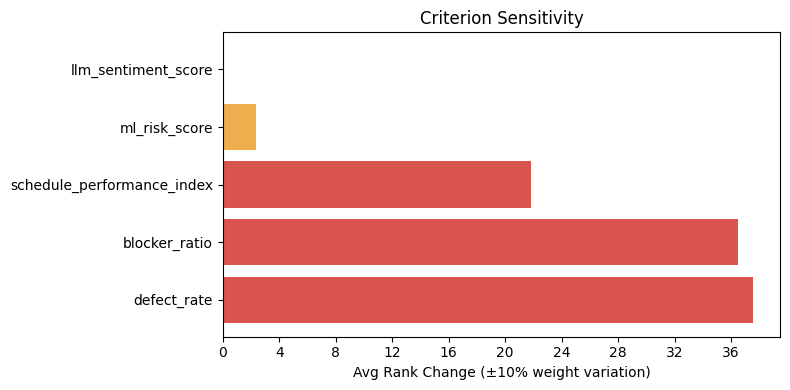

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
crits = [s[0] for s in sens_data]
changes = [s[2] for s in sens_data]

# Traffic-light coloring: red = high influence (>5 rank positions), amber = moderate
# (>2), green = low.  These thresholds are heuristic — they communicate that a
# criterion shifting rankings by more than 5 places on average is "decision-critical".
colors = ['#d9534f' if c > 5 else '#f0ad4e' if c > 2 else '#5cb85c' for c in changes]
ax.barh(crits, changes, color=colors)
ax.set_xlabel('Avg Rank Change (±10% weight variation)')
ax.set_title('Criterion Sensitivity')
# Force integer ticks — fractional rank positions are not meaningful
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. Visualise Rankings

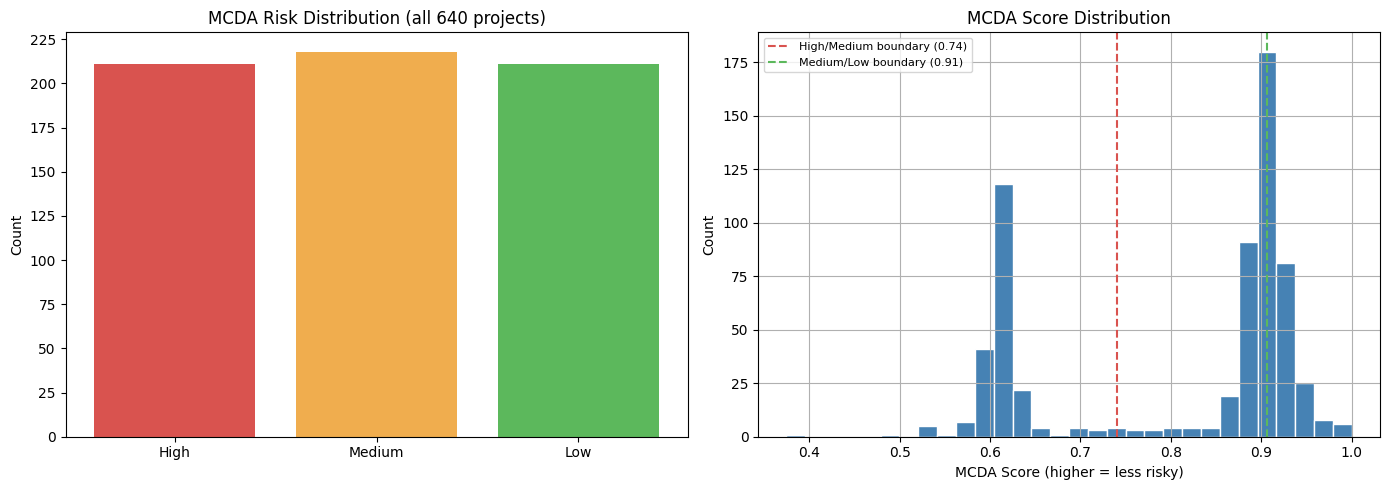

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: risk label counts — should be roughly balanced (~211 each) because
# ProjectRanker uses percentile-based thresholds (33rd / 67th percentile) rather
# than fixed cutoffs, ensuring the distribution mirrors the input ML labels.
risk_counts = rankings['risk_level'].value_counts().reindex(['High', 'Medium', 'Low'], fill_value=0)
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors)
axes[0].set_title('MCDA Risk Distribution (all 640 projects)')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: score histogram with the actual percentile boundaries.
# We recompute them here to match the thresholds used by ProjectRanker so the
# lines align precisely with the labels in the left chart.
scores = rankings['mcda_score'].values
high_threshold = float(np.percentile(scores, 33))   # below this → High risk
low_threshold  = float(np.percentile(scores, 67))   # above this → Low risk

rankings['mcda_score'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(high_threshold, color='#d9534f', linestyle='--',
                label=f'High/Medium boundary ({high_threshold:.2f})')
axes[1].axvline(low_threshold,  color='#5cb85c', linestyle='--',
                label=f'Medium/Low boundary ({low_threshold:.2f})')
axes[1].set_title('MCDA Score Distribution')
axes[1].set_xlabel('MCDA Score (higher = less risky)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

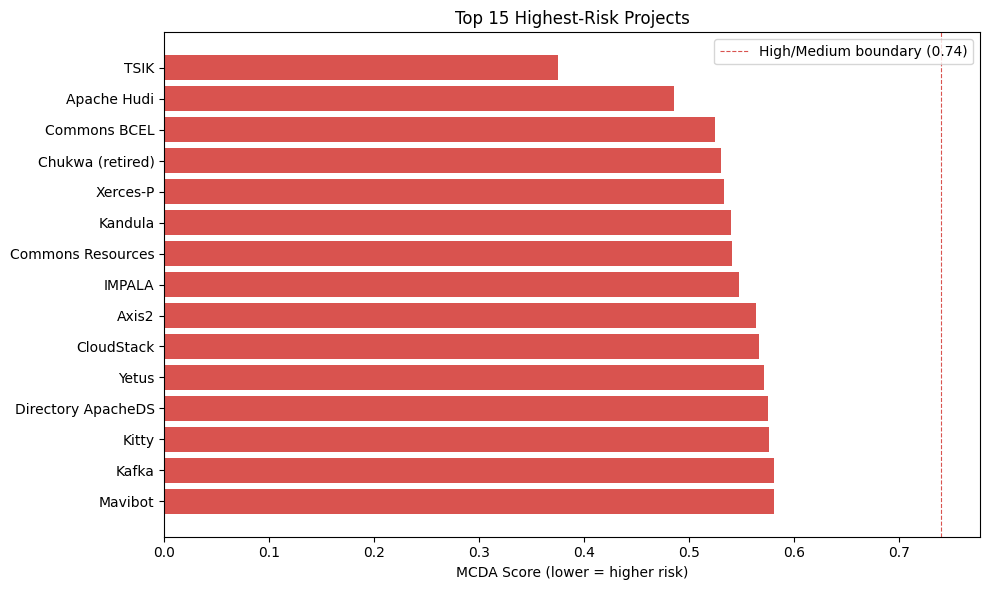

In [10]:
# Top 15 highest-risk projects horizontal bar.
# We use nsmallest on mcda_score because TOPSIS proximity-to-ideal is a
# similarity score: 0 = furthest from ideal (worst), 1 = closest (best).
top15 = rankings.nsmallest(15, 'mcda_score').copy()

# Mirror the percentile boundary so bar colors stay consistent with the histogram above.
bar_colors = ['#d9534f' if s <= high_threshold else '#f0ad4e' for s in top15['mcda_score']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['project_name'], top15['mcda_score'], color=bar_colors)
# Draw the High/Medium boundary so readers can see which bars cross the threshold
ax.axvline(high_threshold, color='#d9534f', linestyle='--', linewidth=0.8,
           label=f'High/Medium boundary ({high_threshold:.2f})')
ax.set_xlabel('MCDA Score (lower = higher risk)')
ax.set_title('Top 15 Highest-Risk Projects')
# invert_yaxis so rank-1 (worst) project appears at the top of the chart
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## 7. ML vs MCDA Risk Label Comparison

How much does the MCDA ranking agree with the original ML binary classification?

In [11]:
merged = rankings.merge(
    df[['project_id', 'risk_level']].rename(columns={'risk_level': 'ml_risk_level'}),
    on='project_id'
)

# We compare on a binary basis (High vs non-High) rather than all three levels
# because the exact Medium/Low boundary is somewhat arbitrary in both the ML model
# (percentile-based label during preprocessing) and the MCDA ranker (percentile-based
# threshold at runtime).  Disagreements between the two systems on whether a project
# is Medium or Low are less actionable than disagreements on whether it is High-risk.
merged['ml_high']   = merged['ml_risk_level'].str.lower() == 'high'
merged['mcda_high'] = merged['risk_level'].str.lower()    == 'high'
agreement_rate = (merged['ml_high'] == merged['mcda_high']).mean()

print(f'ML vs MCDA binary agreement (High vs non-High): {agreement_rate:.1%}')
print()
print('Cross-tabulation (ML rows vs MCDA columns):')
# Off-diagonal cells show the disagreements: ML-High / MCDA-non-High projects
# may need manual review; ML-Low / MCDA-High projects could indicate MCDA criteria
# capturing qualitative risk signals (e.g. blocker ratio) not seen by the ML model.
ct = pd.crosstab(
    merged['ml_risk_level'],
    merged['risk_level'],
    margins=True
)
print(ct)

ML vs MCDA binary agreement (High vs non-High): 96.9%

Cross-tabulation (ML rows vs MCDA columns):
risk_level     High  Low  Medium  All
ml_risk_level                        
High            201    0      10  211
Low               2  153      56  211
Medium            8   58     152  218
All             211  211     218  640


## Summary

### What MCDA adds over the ML model alone
The ML model gives a binary High/Low classification based on historical patterns in structured metrics.
MCDA provides a **continuous score** that orders *all* projects, enabling prioritisation within risk tiers
and allowing stakeholders to tune the importance of each dimension via weights.

### Design decisions
| Decision | Choice | Reason |
|---|---|---|
| MCDA method | TOPSIS | Conceptually transparent; score = geometric proximity to ideal/anti-ideal solution, easy to explain to non-technical stakeholders |
| ML score as primary criterion | 40% weight | The trained classifier already aggregates all structured features — making it the anchor prevents MCDA from "double-counting" those signals via lower-level criteria |
| LLM sentiment at 25% | `benefit` type | Positive sentiment reduces perceived risk; neutral default (0.0) means the criterion has no effect until real LLM analysis is run on all projects |
| Risk label thresholds | Percentile-based (33rd / 67th) | Fixed thresholds produced skewed distributions (e.g. 1 High, 639 Low) because TOPSIS scores are relative to the dataset; percentile thresholds adapt automatically and mirror the balanced ML label distribution |
| Sensitivity variation | ±10% absolute | Represents realistic stakeholder disagreement; larger perturbations would be unrealistic given weights sum to 1.0 |
| Binary agreement metric | High vs non-High | The exact Medium/Low boundary is somewhat arbitrary in both systems (both use percentile-based thresholds); disagreements on High-risk identification are the most consequential |

### Default criteria (TOPSIS)
| Criterion | Weight | Type | Rationale |
|---|---|---|---|
| `ml_risk_score` | 40% | cost | ML model probability — strongest signal |
| `llm_sentiment_score` | 25% | benefit | Text sentiment from LLM; defaults to neutral (0) when not available |
| `schedule_performance_index` | 15% | benefit | Earned-value proxy for schedule health |
| `blocker_ratio` | 10% | cost | Proportion of blocker issues — top ML feature |
| `defect_rate` | 10% | cost | Bug density |

### Key findings from this run
- **Sensitivity paradox**: `ml_risk_score` (40% weight) causes only avg rank change of **2.36** when varied ±10%, while `defect_rate` (10%) causes **37.59**. This is because `ml_risk_score` is strongly bimodal (High ≈ 0.95, Low ≈ 0.00) — the ordering is locked in regardless of weight. `defect_rate` and `blocker_ratio` are continuous, so weight changes shuffle more projects across rank boundaries.
- **TSIK anomaly**: The only project below the High threshold is TSIK (ML-classified as Low risk), which has extreme `blocker_ratio` and `defect_rate` values that override the low ML probability — a genuine case where MCDA surfaces something the ML model misses.
- **LLM criterion currently flat**: All 640 projects default to `sentiment_score = 0.0` (neutral) since LLM analysis was only run on 10 projects in notebook 04. Running the full batch would activate the 25% LLM weight and likely change rankings significantly.
- **Weight profile agreement**: Balanced vs Schedule-focused share 80% of top-20; Balanced vs Quality-focused share 75%. The 20–25% disagreement shows the profiles are genuinely different rather than redundant.
- **ML vs MCDA alignment**: 96.9% binary agreement after switching to percentile-based MCDA thresholds. The remaining 3.1% represent projects where MCDA criteria (especially continuous blocker/defect signals) override the ML binary classification — these are the most interesting candidates for manual review.
- **Threshold lines in plots**: The histogram and bar chart now draw threshold lines at the actual computed percentile values rather than fixed constants, so they always match the labels shown in the distribution chart.

### Next Steps
1. Run notebook 04 on all 640 projects to populate real `sentiment_score` values, then re-run MCDA with live LLM scores — this will activate the 25% LLM weight and likely change rankings significantly
2. Deploy ranked results in the Streamlit dashboard (`06_dashboard_preview.ipynb`)
3. Expose weight sliders in the dashboard for real-time what-if analysis